In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("data_synthetic_.csv")

In [3]:
df.head()

,Customer ID,Age,Gender,Marital Status,Occupation,Income Level,Education Level,Geographic Information,Location,Behavioral Data,...,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Risk Profile,Previous Claims History,Credit Score,Driving Record,Life Events,Segmentation Group
0,84966,23.0,Female,Married,Entrepreneur,70541.0,Associate Degree,Mizoram,37534,policy5,...,Email,In-Person Meeting,Afternoon,English,1,3,728.0,DUI,Job Change,Segment5
1,95568,26.0,Male,Widowed,Manager,54168.0,Doctorate,Goa,63304,policy5,...,Mail,In-Person Meeting,Morning,French,1,2,792.0,Clean,Retirement,Segment5
2,10544,29.0,Female,Single,Entrepreneur,73899.0,Associate Degree,Rajasthan,53174,policy5,...,Email,Mail,Evening,German,2,1,719.0,Accident,Childbirth,Segment3
3,77033,20.0,Male,Divorced,Entrepreneur,63381.0,Bachelor's Degree,Sikkim,22803,policy5,...,Text,In-Person Meeting,Anytime,French,3,0,639.0,DUI,Job Change,Segment3
4,88160,25.0,Female,Separated,Manager,38794.0,Bachelor's Degree,West Bengal,92858,policy1,...,Email,Text,Weekends,English,0,3,720.0,Major Violations,Childbirth,Segment2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54503 entries, 0 to 54502
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer ID                         54503 non-null  int64  
 1   Age                                 53503 non-null  float64
 2   Gender                              54503 non-null  object 
 3   Marital Status                      54503 non-null  object 
 4   Occupation                          54503 non-null  object 
 5   Income Level                        53997 non-null  float64
 6   Education Level                     54503 non-null  object 
 7   Geographic Information              54503 non-null  object 
 8   Location                            54503 non-null  int64  
 9   Behavioral Data                     54503 non-null  object 
 10  Purchase History                    54503 non-null  object 
 11  Policy Start Date                   54503

In [5]:
df.isnull().sum()

Customer ID                              0
Age                                   1000
Gender                                   0
Marital Status                           0
Occupation                               0
Income Level                           506
Education Level                          0
Geographic Information                   0
Location                                 0
Behavioral Data                          0
Purchase History                         0
Policy Start Date                        0
Policy Renewal Date                      0
Claim History                            0
Interactions with Customer Service       0
Insurance Products Owned                 0
Coverage Amount                          0
Premium Amount                         508
Deductible                               0
Policy Type                              0
Customer Preferences                     0
Preferred Communication Channel          0
Preferred Contact Time                   0
Preferred L

In [6]:
df.duplicated().sum()

np.int64(1000)

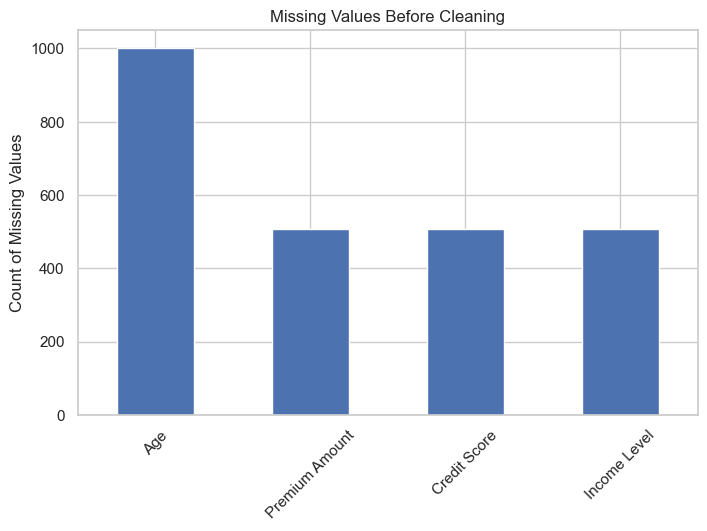

In [8]:
# Missing values before cleaning
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(8,5))
missing_counts.sort_values(ascending=False).plot(kind="bar")
plt.title("Missing Values Before Cleaning")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45)
plt.show()

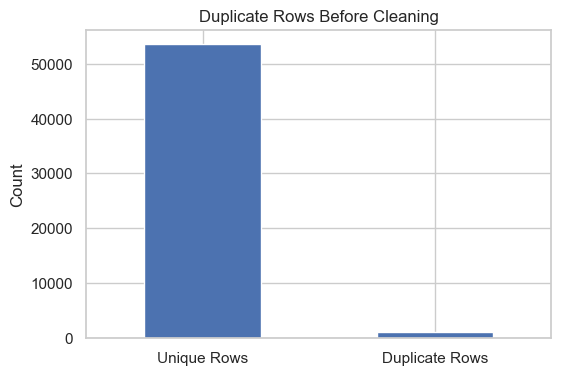

In [9]:
# Duplicate rows before cleaning

dup_counts = pd.Series({
    "Unique Rows": len(df) - df.duplicated().sum(),
    "Duplicate Rows": df.duplicated().sum()
})

plt.figure(figsize=(6,4))
dup_counts.plot(kind="bar")
plt.title("Duplicate Rows Before Cleaning")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

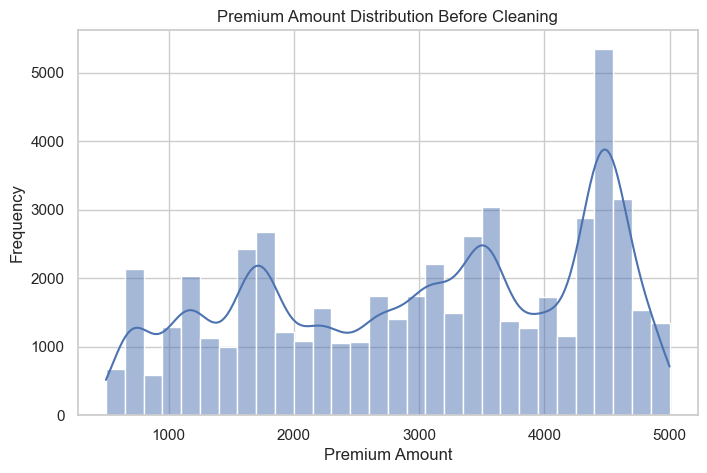

In [11]:
#Premium amount distribution before cleaning

plt.figure(figsize=(8,5))
sns.histplot(df["Premium Amount"], bins=30, kde=True)
plt.title("Premium Amount Distribution Before Cleaning")
plt.xlabel("Premium Amount")
plt.ylabel("Frequency")
plt.show()

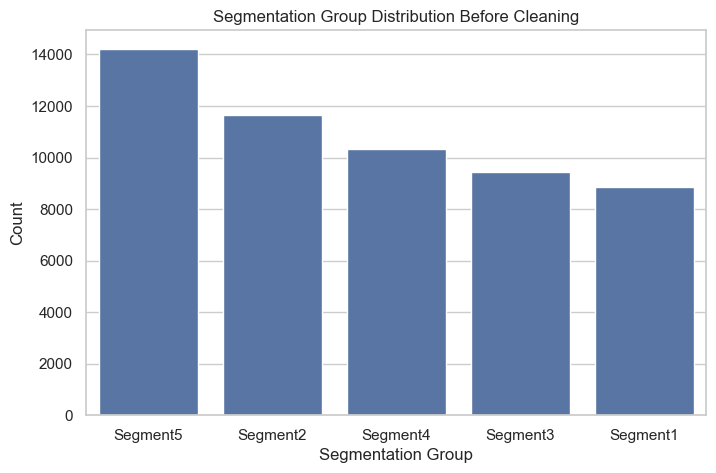

In [12]:
# Segmentation group distribution before cleaning

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Segmentation Group", order=df["Segmentation Group"].value_counts().index)
plt.title("Segmentation Group Distribution Before Cleaning")
plt.xlabel("Segmentation Group")
plt.ylabel("Count")
plt.show()

After EDA

In [13]:
df = df.drop_duplicates()
print("Shape after duplicate removal:", df.shape)

Shape after duplicate removal: (53503, 30)


In [14]:
# Handle missing values with median imputation
cols_with_missing = ["Age", "Income Level", "Premium Amount", "Credit Score"]

for col in cols_with_missing:
    df[col] = df[col].fillna(df[col].median())

In [15]:
print("Remaining missing values:", df.isnull().sum().sum())
print("Remaining duplicates:", df.duplicated().sum())

Remaining missing values: 0
Remaining duplicates: 0


In [17]:
# Convert date columns

df["Policy Start Date"] = pd.to_datetime(df["Policy Start Date"], format="mixed")
df["Policy Renewal Date"] = pd.to_datetime(df["Policy Renewal Date"], format="mixed")

Explanation

Date columns were stored as text and had to be converted for time-based analysis.

In [18]:
# Create derived features

df["Policy Tenure Days"] = (df["Policy Renewal Date"] - df["Policy Start Date"]).dt.days
df["Policy Start Year"] = df["Policy Start Date"].dt.year
df["Policy Start Month"] = df["Policy Start Date"].dt.month

In [20]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numerical columns: ['Customer ID', 'Age', 'Income Level', 'Location', 'Claim History', 'Coverage Amount', 'Premium Amount', 'Deductible', 'Risk Profile', 'Previous Claims History', 'Credit Score', 'Policy Tenure Days', 'Policy Start Year', 'Policy Start Month']

Categorical columns: ['Gender', 'Marital Status', 'Occupation', 'Education Level', 'Geographic Information', 'Behavioral Data', 'Purchase History', 'Policy Start Date', 'Policy Renewal Date', 'Interactions with Customer Service', 'Insurance Products Owned', 'Policy Type', 'Customer Preferences', 'Preferred Communication Channel', 'Preferred Contact Time', 'Preferred Language', 'Driving Record', 'Life Events', 'Segmentation Group']


AttritionFlag helps with correlation analysis

AgeGroup helps compare attrition by age range

In [27]:
# Separate numerical and categorical columns

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numerical columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'AttritionFlag']

Categorical columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'AgeGroup']


/var/folders/09/51ry86dd4ws34ds6szhwnzs00000gn/T/ipykernel_28693/4199906684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


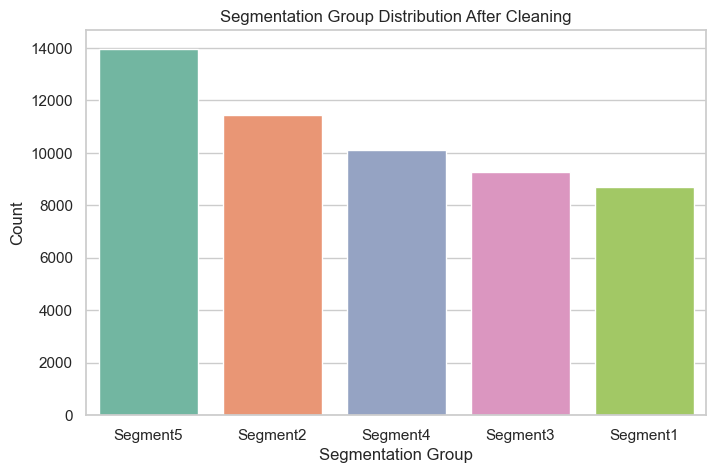

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Segmentation Group",
    order=df["Segmentation Group"].value_counts().index,
    palette="Set2" 
)

plt.title("Segmentation Group Distribution After Cleaning")
plt.xlabel("Segmentation Group")
plt.ylabel("Count")
plt.show()

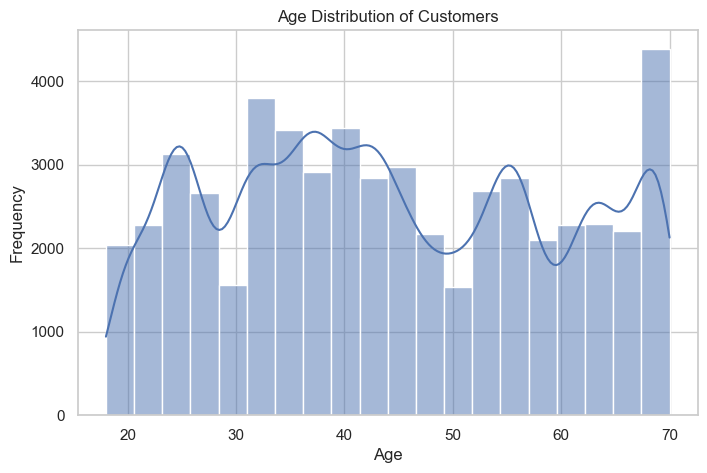

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

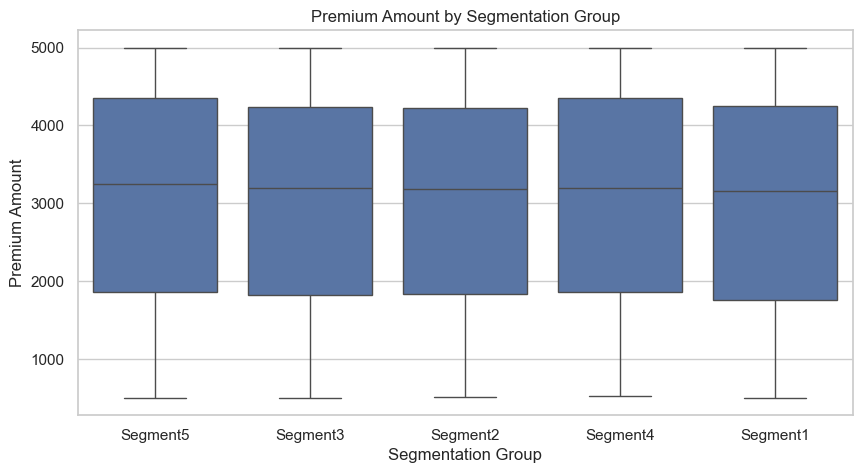

In [31]:
# Premium amount by segmentation group

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Segmentation Group", y="Premium Amount")
plt.title("Premium Amount by Segmentation Group")
plt.xlabel("Segmentation Group")
plt.ylabel("Premium Amount")
plt.show()

Insight

Some segments appear to have higher premium distributions than others

Financial variables likely help explain segmentation

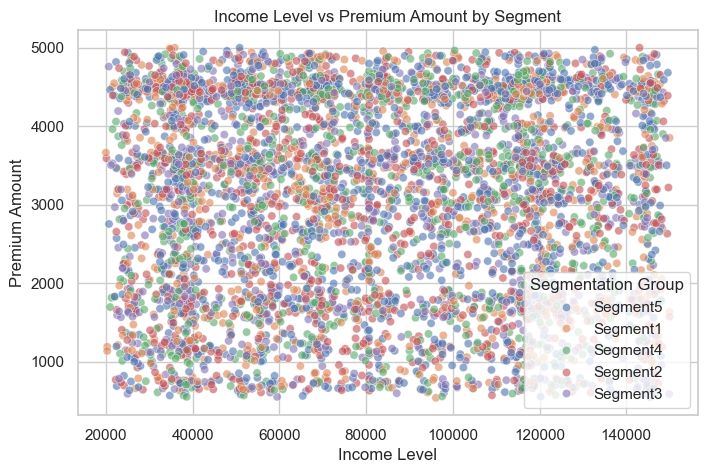

In [32]:
# Income level vs premium amount by segment

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="Income Level",
    y="Premium Amount",
    hue="Segmentation Group",
    alpha=0.6
)
plt.title("Income Level vs Premium Amount by Segment")
plt.xlabel("Income Level")
plt.ylabel("Premium Amount")
plt.show()

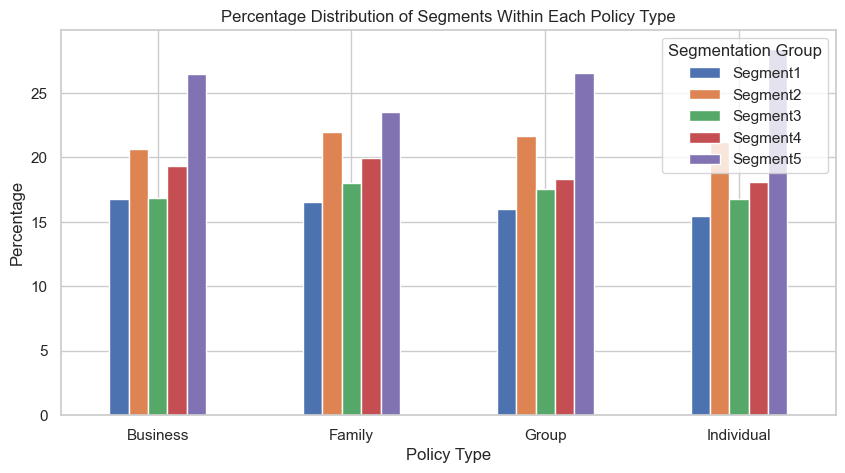

In [34]:
# Policy type vs segmentation group
policy_seg_pct = pd.crosstab(df["Policy Type"], df["Segmentation Group"], normalize="index") * 100

policy_seg_pct.plot(kind="bar", figsize=(10,5))
plt.title("Percentage Distribution of Segments Within Each Policy Type")
plt.xlabel("Policy Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

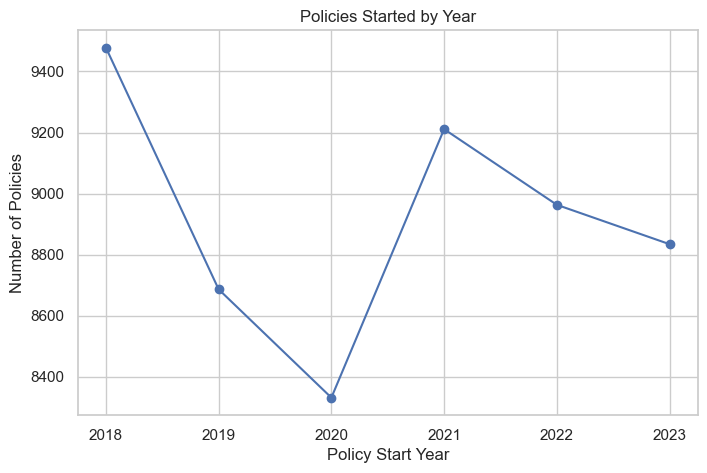

In [37]:
# Policy starts over time
policies_by_year = df.groupby("Policy Start Year").size()

plt.figure(figsize=(8,5))
policies_by_year.plot(marker="o")
plt.title("Policies Started by Year")
plt.xlabel("Policy Start Year")
plt.ylabel("Number of Policies")
plt.show()